# Nyquist, Taxa de Símbolos e Taxa Útil, com Dados Reais

Nesse laborátorio vocês vão analisar a gravação real de um transmissor de rádio e comparar **três taxas
diferentes** do mesmo sistema:

1. O **limite teórico** que a física do canal permite (calculado por vocês, a partir de uma
   medição que vocês mesmos vão fazer).
2. A **taxa de símbolos** que o protocolo realmente usa.
3. A **taxa útil** (goodput) de informação efetivamente entregue.

As três são muito diferentes entre si, e explicar por que elas diferem é o objetivo central
do laboratório.

- [Que sinal é esse? TPMS?](#Que-sinal-é-esse?-TPMS?)
- [Definições: símbolo, baud e bit por segundo](#Definições:-símbolo,-baud-e-bit-por-segundo)
  - [O teorema de Nyquist](#O-teorema-de-Nyquist)
- [Mãos a obra](#Mãos-a-obra)
  - [Carregando os dados](#Carregando-os-dados)
  - [Cadê as transmissões?](#Cadê-as-transmissões?)
  - [Pergunta 1](#Pergunta-1)
  - [Medindo a largura de banda](#Medindo-a-largura-de-banda)
  - [Pergunta 2 (medição)](#Pergunta-2-(medição))
  - [Limite teórico de Nyquist](#Limite-teórico-de-Nyquist)
  - [A taxa de símbolos do protocolo](#A-taxa-de-símbolos-do-protocolo)
  - [Pergunta 3](#Pergunta-3)
  - [A Taxa útil (goodput)](#A-Taxa-útil-(goodput))
  - [Comparando as três taxas](#Comparando-as-três-taxas)
  - [Pergunta 4 (síntese)](#Pergunta-4-(síntese))
- [Praticando](#Praticando)
  - [Pergunta 5](#Pergunta-5)
- [Entrega](#Entrega)


Para executar vocês precisam das bibliotecas:

- numpy
- matplotlib
- pandas
- scipy

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

## Que sinal é esse? TPMS?

O sinal analisado neste lab vem de um **TPMS** (*Tire Pressure Monitoring System*, ou sistema
de monitoramento de pressão dos pneus). Vale a pena destacar que as restrições desse dispositivo 
explicam praticamente todas as decisões de projeto que aparecerão nas medições.

![](imgs/compass.png)

O TPMS é um pequeno sensor instalado **dentro de cada pneu** do carro, preso à válvula ou à
roda. Ele mede a pressão e a temperatura do pneu e transmite essas informações por rádio para
o computador de bordo, que acende a luz de "calibrar pneu" no painel. Esse sistema é
obrigatório por lei em veículos novos nos Estados Unidos e na União Europeia desde os anos
2000, motivo pelo qual praticamente todo carro moderno tem um.

![](imgs/sensor.png)

As restrições de engenharia desse dispositivo são severas:

- **Bateria não recarregável e não substituível.** O sensor fica lacrado dentro do pneu e deve
  durar de 5 a 10 anos. Cada milissegundo transmitindo consome energia que nunca será
  reposta.
- **Ambiente hostil.** O sensor está dentro de uma roda de metal, girando em alta velocidade.
  Metal bloqueia sinais de rádio, e a rotação faz a orientação da antena mudar continuamente.
- **Sem canal de retorno.** O sensor apenas transmite; ele nunca recebe nada. Não existe
  confirmação de recebimento (o que em redes chamaríamos de ACK), nem possibilidade de
  retransmissão sob demanda. O sensor transmite "às cegas", sem nunca saber se a mensagem
  chegou.


### O modelo específico

O sensor usado aqui é um **Jansite TY02S**. A documentação do fabricante e a engenharia
reversa feita pela comunidade nos dão os seguintes dados:

| Parâmetro | Valor |
|---|---|
| Frequência de operação | 433,92 MHz ± 38 kHz |
| Modulação | FSK |
| Duração de cada símbolo | 52 µs |
| Tamanho do pacote | 7 bytes (56 bits) |

O conteúdo dos **56 bits**: 

- 28 bits de identificação do sensor
- 4 bits de status (bateria fraca, alarme de esvaziamento)
- 8 bits de pressão
- 8 bits de temperatura
- 8 bits de checksum.

### A faixa de 433,92 MHz

Essa frequência pertence a uma **faixa ISM** (*Industrial, Scientific and Medical*), que são
faixas de uso livre: qualquer fabricante pode transmitir nelas sem pedir licença ao órgão
regulador, desde que respeite limites de potência. É por isso que controles de portão,
sensores de alarme, estações meteorológicas domésticas e sensores de pneu convivem todos na
mesma faixa, sem coordenação central entre eles.

### A modulação FSK

**FSK** (*Frequency Shift Keying*) representa os bits deslocando a **frequência** do sinal
entre dois valores: uma frequência significa 0, outra significa 1. A amplitude (a "força" do
sinal) permanece constante o tempo todo.

Essa distinção terá uma consequência prática direta neste lab, e vocês verão qual daqui a
pouco.

### De onde vieram os dados

A gravação foi feita com um receptor **RTL-SDR** (um rádio USB de baixo custo, capaz de
gravar sinais de rádio de forma bruta) e está publicada no banco de testes aberto do projeto
de código aberto `rtl_433`, que desenvolve decodificadores para sensores sem fio:

<https://github.com/merbanan/rtl_433_tests>

## Definições: símbolo, baud e bit por segundo

Estes três termos aparecem o tempo todo daqui em diante e são frequentemente confundidos.

**Símbolo** é a unidade física que o transmissor realmente coloca no ar durante um intervalo
de tempo fixo. No FSK deste sensor, um símbolo é "manter uma determinada frequência durante
52 µs".

**Taxa de símbolos**, medida em **baud**, é quantos símbolos são transmitidos por segundo.
Como cada símbolo aqui dura 52 µs, a taxa é 1 ÷ 52 µs ≈ 19.230 baud.

**Taxa de bits**, medida em bit/s, é quanta informação é transmitida por segundo.

A diferença entre as duas últimas depende de **quantos níveis distintos** um símbolo pode
assumir. Se um símbolo só pode ser uma entre duas frequências possíveis, ele carrega
exatamente 1 bit, e então 19.230 baud equivalem a 19.230 bit/s. Mas se o sistema usasse
quatro frequências distintas, cada símbolo poderia representar uma entre quatro
possibilidades, ou seja, 2 bits, e a mesma taxa de símbolos entregaria o dobro de bits por
segundo.

Formalmente, um sistema com $L$ níveis distintos carrega $\log_2(L)$ bits por símbolo.

> **Neste lab**, o sensor usa FSK binário, com $L = 2$, logo $\log_2(2) = 1$ bit por símbolo.
> Baud e bit/s coincidem numericamente. Não confundam isso com um caso geral: a coincidência
> é uma particularidade deste sistema.

### O teorema de Nyquist

Nyquist estabelece o **teto teórico** de um canal de comunicação sem ruído:

$$ C = 2B \log_2(L) $$

onde $B$ é a largura de banda do canal (em Hz), $L$ é o número de níveis distintos por
símbolo, e $C$ é a taxa máxima de bits (em bit/s).

A fórmula tem duas partes com significados distintos:

- O fator $2B$ é a **taxa máxima de símbolos** que a banda comporta. Um canal mais largo
  permite símbolos mais curtos, portanto mais símbolos por segundo.
- O fator $\log_2(L)$ é **quantos bits cada símbolo carrega**.

Para o FSK binário deste sensor, com $L = 2$, a fórmula se reduz a $C = 2B$.

**Atenção a um detalhe importante:** para aplicar Nyquist é preciso conhecer $B$, a banda do
sinal. Esse valor **não** está escrito em lugar nenhum do arquivo de dados. Vocês terão que
medi-lo.

## Mãos a obra

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

### Carregando os dados

A célula abaixo carrega o arquivo. Dois valores importantes ficam claros aqui:

A **taxa de amostragem** de 250.000 Hz indica quantas vezes por segundo o receptor RTL-SDR
"tirou uma foto" do sinal de rádio durante a gravação. Esse número foi uma escolha de quem
fez a gravação, uma configuração de hardware.

> **Cuidado com o erro mais comum deste lab:** a taxa de amostragem **não é** a largura de
> banda do sinal. São coisas conceitualmente diferentes. A taxa de amostragem descreve o
> *receptor*; a largura de banda descreve o *sinal*. Vocês vão medir a segunda mais adiante.
> - nas proximas aulas explicarei isso

In [9]:
# codigo gerado por LLM

def carregar_gravacao(caminho):
    """Carrega uma gravacao de radio feita por um RTL-SDR."""
    # O formato .cu8 guarda o sinal como bytes sem sinal (0 a 255), onde o valor
    # central 127,5 representa "sinal zero". A subtracao e a divisao abaixo
    # convertem esses bytes de volta para a faixa util de -1 a +1.
    bytes_brutos = np.fromfile(caminho, dtype=np.uint8)
    valores = (bytes_brutos.astype(np.float32) - 127.5) / 127.5

    # O receptor grava DUAS medicoes simultaneas do sinal, intercaladas no arquivo
    # (uma nas posicoes pares, outra nas impares). Juntas, elas descrevem
    # completamente o sinal de radio. A combinacao em um unico valor complexo e
    # apenas a forma padrao de guardar esse par; nao e necessario entende-la em
    # detalhe para este laboratorio.
    return valores[0::2] + 1j * valores[1::2]

lendo os dados

In [10]:
TAXA_AMOSTRAGEM = 250_000  # Dados descritos logoacima

sinal = carregar_gravacao("../dados/tpms_jansite_433.92M_250k.cu8")

duracao_ms = len(sinal) / TAXA_AMOSTRAGEM * 1000
print(f"Amostras na gravacao: {len(sinal)}")
print(f"Duracao total: {duracao_ms:.1f} ms")

Amostras na gravacao: 97621
Duracao total: 390.5 ms


In [11]:
sinal

array([0.00392157+0.00392157j, 0.00392157+0.00392157j,
       0.00392157+0.00392157j, ..., 0.00392157-0.00392157j,
       0.01176471+0.00392157j, 0.00392157+0.00392157j],
      shape=(97621,), dtype=complex64)

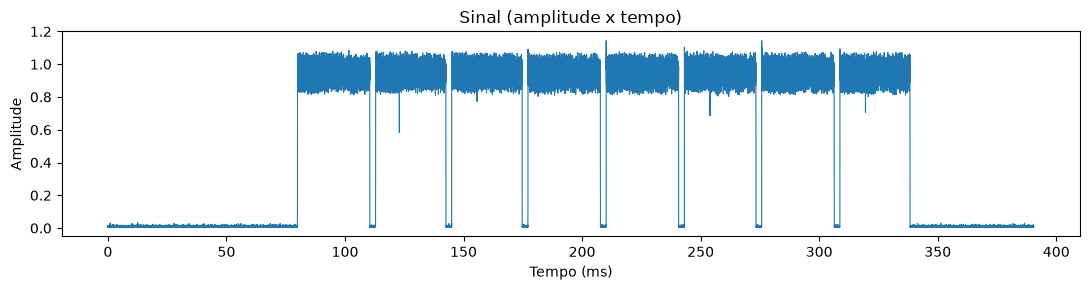

In [12]:
t_ms = np.arange(len(sinal)) / TAXA_AMOSTRAGEM * 1000

plt.figure(figsize=(11, 3))
plt.plot(t_ms, np.abs(sinal), lw=0.8)
plt.xlabel("Tempo (ms)")
plt.ylabel("Amplitude")
plt.title("Sinal (amplitude x tempo)")
plt.tight_layout()
plt.show()

### Cadê as transmissões?

O sensor não transmite continuamente; ele economiza bateria transmitindo apenas em rajadas
curtas. A maior parte da gravação é, portanto, apenas ruído de fundo.

Antes de medir qualquer coisa, precisamos localizar **quando** houve transmissão. A função abaixo faz isso automaticamente.

#### Como a detecção funciona

O método se baseia na **amplitude** do sinal ao longo do tempo. Quando não há transmissão,
sobra apenas ruído de fundo, de amplitude baixa. Quando o sensor transmite, a amplitude sobe
bruscamente. A função calcula um limiar entre esses dois patamares e marca como "transmissão"
todo trecho acima dele.

Este método funciona particularmente bem aqui por causa da modulação FSK: como o FSK mantém a
**amplitude constante** e varia apenas a frequência, amplitude alta significa, sem
ambiguidade, "transmitindo".

In [13]:
# codigo gerado por LLM
# prompt: "Escreva uma funcao em Python que identifique automaticamente os trechos de uma gravacao de radio em que houve transmissao. A funcao deve receber como entrada o sinal, a taxa de amostragem e a duracao minima de uma transmissao em milissegundos. A funcao deve retornar uma lista de tuplas (inicio_s, fim_s) em segundos, representando os trechos detectados. A funcao deve tambem plotar o envelope do sinal e marcar os trechos detectados."

def identificar_transmissoes(sinal, taxa_amostragem, duracao_minima_ms=1.0, mostrar=True):
    """Localiza automaticamente os trechos da gravacao em que houve transmissao.

    Retorna uma lista de tuplas (inicio_s, fim_s), em segundos.
    """
    # Amplitude instantanea do sinal
    amplitude = np.abs(sinal)

    # Suavizacao: media movel para remover variacoes muito rapidas e deixar
    # visivel apenas o "contorno" (envelope) do sinal
    janela = max(1, int(0.4e-3 * taxa_amostragem))
    envelope = np.convolve(amplitude, np.ones(janela) / janela, mode="same")

    # Limiar a meio caminho entre o patamar de ruido e o patamar de sinal
    patamar_ruido = np.percentile(envelope, 10)
    patamar_sinal = np.percentile(envelope, 90)
    limiar = (patamar_ruido + patamar_sinal) / 2

    # Trechos contiguos acima do limiar
    ativo = envelope > limiar
    transicoes = np.diff(ativo.astype(int))
    inicios = np.where(transicoes == 1)[0] + 1
    fins = np.where(transicoes == -1)[0] + 1
    if ativo[0]:
        inicios = np.r_[0, inicios]
    if ativo[-1]:
        fins = np.r_[fins, len(ativo)]

    # Descarta trechos curtos demais para serem uma transmissao real
    minimo = int(duracao_minima_ms * 1e-3 * taxa_amostragem)
    trechos = [(i / taxa_amostragem, f / taxa_amostragem)
               for i, f in zip(inicios, fins) if (f - i) >= minimo]

    if mostrar:
        t_ms = np.arange(len(envelope)) / taxa_amostragem * 1000
        plt.figure(figsize=(11, 3.5))
        plt.plot(t_ms, envelope, lw=0.8, label="amplitude do sinal")
        plt.axhline(limiar, color="orange", ls="--", lw=1, label="limiar de deteccao")
        for k, (ti, tf) in enumerate(trechos):
            plt.axvspan(ti * 1000, tf * 1000, alpha=0.25, color="tab:green")
            plt.text((ti + tf) / 2 * 1000, envelope.max() * 1.03, str(k + 1),
                     ha="center", fontsize=9)
        plt.xlabel("Tempo (ms)")
        plt.ylabel("Amplitude")
        plt.title(f"{len(trechos)} transmissoes detectadas")
        plt.legend(loc="center right", fontsize=8)
        plt.tight_layout()
        plt.show()

    return trechos

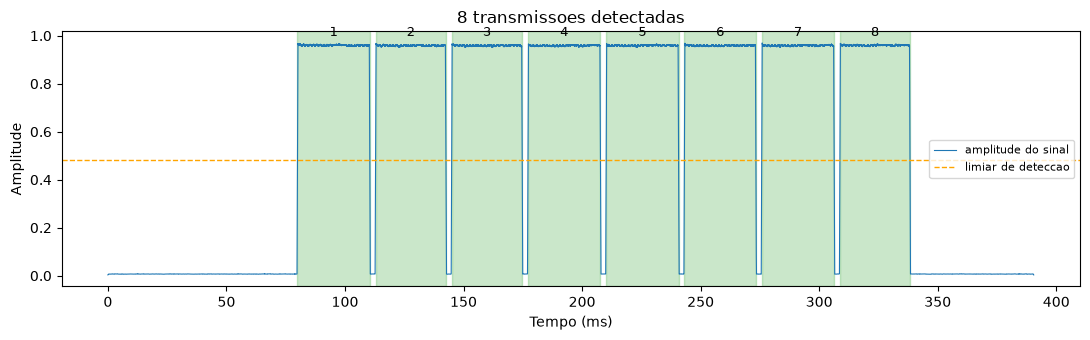

In [14]:
transmissoes = identificar_transmissoes(sinal, TAXA_AMOSTRAGEM)

In [15]:
print(f"Transmissoes detectadas: {len(transmissoes)}\n")
for k, (inicio, fim) in enumerate(transmissoes):
    print(f"  transmissao {k+1}: inicio = {inicio*1000:7.2f} ms   "
          f"duracao = {(fim-inicio)*1000:6.2f} ms")

Transmissoes detectadas: 8

  transmissao 1: inicio =   79.96 ms   duracao =  30.49 ms
  transmissao 2: inicio =  112.90 ms   duracao =  29.64 ms
  transmissao 3: inicio =  144.99 ms   duracao =  29.74 ms
  transmissao 4: inicio =  177.18 ms   duracao =  30.54 ms
  transmissao 5: inicio =  210.16 ms   duracao =  30.54 ms
  transmissao 6: inicio =  243.15 ms   duracao =  30.16 ms
  transmissao 7: inicio =  275.76 ms   duracao =  30.54 ms
  transmissao 8: inicio =  308.74 ms   duracao =  29.55 ms


#### Observem o resultado

O gráfico mostra claramente o padrão: vários blocos de transmissão, de duração muito parecida,
separados por intervalos curtos de silêncio.

**Anotem o número de transmissões detectadas.** Utilizaremos mais a frentes

### Pergunta 1

Todas as transmissões detectadas têm aproximadamente a mesma duração e estão separadas por
intervalos regulares. O que isso sugere sobre o que o sensor está fazendo? Ele está enviando
oito informações diferentes, ou outra coisa?

*(Anote sua resposta; ela será pedida no formulário de entrega.)*

### Medindo a largura de banda

Agora vamos examinar **uma** dessas transmissões no domínio da frequência, para medir a
largura de banda que ela ocupa.

#### O função `osciloscopio()`

A função abaixo funciona como um osciloscópio. Um osciloscópio mostra um sinal em
função do tempo; a função `osciloscopio()` mostra a **potência em função da frequência**, isto é,
quanta energia o sinal tem em cada faixa de frequência.

Uma analogia útil: pensem no equalizador gráfico de um aplicativo de música, com barras
subindo e descendo para mostrar quanta energia existe nos graves, médios e agudos. É a mesma
ideia, com resolução muito maior.

A matemática por trás dessa transformação (a Transformada de Fourier) será vista adiante na
disciplina. Por ora, usem a função como um instrumento: vocês vão **ler** o gráfico, não
implementá-lo.

#### Dois detalhes para ler o gráfico corretamente

**O eixo horizontal mostra um deslocamento, não uma frequência absoluta.** O receptor foi
sintonizado em 433,92 MHz, e o valor 0 no eixo corresponde exatamente a essa frequência. Um
ponto marcado em +30 kHz significa, na verdade, 433,95 MHz.

**O eixo vertical está em decibéis (dB), uma escala logarítmica.** Sinais de rádio cobrem uma
faixa enorme de intensidades, e uma escala linear tornaria o gráfico ilegível. O que importa
para vocês é a leitura relativa: uma queda de 20 dB significa que a potência caiu 100 vezes

In [16]:
def osciloscopio(sinal, taxa_amostragem, titulo=""):
    """Instrumento de medicao: mostra a potencia do sinal em funcao da frequencia."""
    nperseg = min(1024, len(sinal))
    f, potencia = signal.welch(sinal, fs=taxa_amostragem, nperseg=nperseg,
                               noverlap=nperseg // 2, return_onesided=False)
    f = np.fft.fftshift(f)
    potencia_db = 10 * np.log10(np.fft.fftshift(potencia) + 1e-20)

    plt.figure(figsize=(10, 4))
    plt.plot(f / 1e3, potencia_db, lw=0.9)
    plt.xlabel("Deslocamento em relacao a 433,92 MHz (kHz)")
    plt.ylabel("Potencia (dB)")
    plt.title(titulo)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return f, potencia_db

Analisando a transmissao 1: de 79.96 ms a 110.45 ms


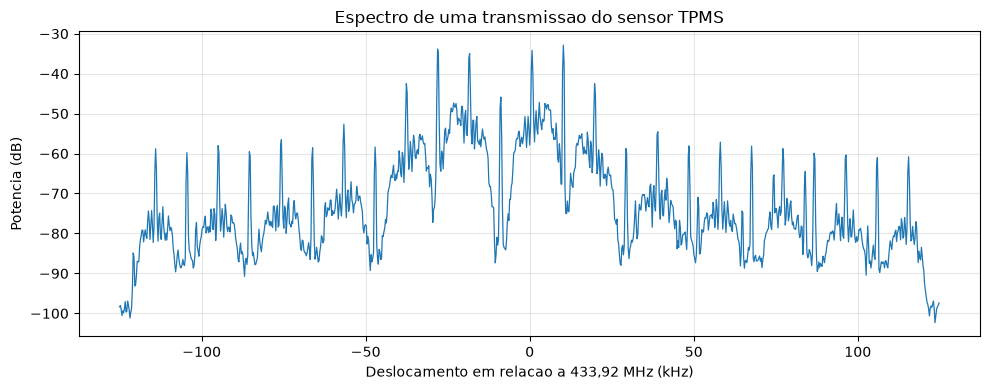

In [17]:
# Recorta a PRIMEIRA transmissao detectada na Parte 4.
# O recorte e necessario porque o espectro da gravacao inteira misturaria o sinal
# com os longos trechos de silencio, mascarando a medicao.
inicio_s, fim_s = transmissoes[0]
primeira = sinal[int(inicio_s * TAXA_AMOSTRAGEM):int(fim_s * TAXA_AMOSTRAGEM)]

print(f"Analisando a transmissao 1: de {inicio_s*1000:.2f} ms a {fim_s*1000:.2f} ms")
osciloscopio(primeira, TAXA_AMOSTRAGEM, "Espectro de uma transmissao do sensor TPMS");

#### Como ler este gráfico

Dados reais não se parecem com figuras de livro-texto. Vocês verão alguns **picos estreitos e
isolados** espalhados pelo gráfico: isso é ruído do próprio receptor, comum em rádios de baixo
custo, e não faz parte do sinal do sensor.

O que vocês procuram é a região **contígua** onde a energia se mantém consistentemente elevada
acima do ruído de fundo. Uma referência prática: considerem os limites da região como os
pontos onde a potência já caiu cerca de 20 dB em relação ao pico.

### Pergunta 2 (medição)

Leiam no gráfico os limites esquerdo e direito da região de energia elevada e preencham a
célula abaixo com a largura de banda correspondente.

In [1]:
# TODO: leiam o grafico acima e preencham a largura de banda medida, em Hz.
#
# Exemplo de raciocinio: se a energia elevada vai de -45 kHz ate +45 kHz,
# a largura de banda e de 90 kHz, ou seja, 90_000 Hz.
#
# ATENCAO: este valor vem da SUA leitura do grafico. Nao e a taxa de amostragem
# do receptor (250_000 Hz), nem nenhum outro numero fornecido no enunciado.

B_medida_hz = 75000

assert B_medida_hz is not None, "Preencha B_medida_hz com a banda lida no grafico."
print(f"Largura de banda medida: {B_medida_hz/1e3:.1f} kHz")

Largura de banda medida: 75.0 kHz


### Limite teórico de Nyquist

Com a banda medida, apliquem o teorema de Nyquist.

Lembrem que este sensor usa FSK **binário**: cada símbolo assume uma entre duas frequências
possíveis.

In [4]:
# TODO: quantos niveis distintos um simbolo pode assumir neste sistema?
# TODO: IMplementar a formula de Nyquist, C = 2 * B * log2(L)
L = 2

# TODO: apliquem a formula de Nyquist, C = 2 * B * log2(L)
# Dica: np.log2(L) calcula o logaritmo na base 2.
C_nyquist = 2 * B_medida_hz * np.log2(L)

assert L is not None, "Preencha L com o numero de niveis do FSK binario."
assert C_nyquist is not None, "Calcule C_nyquist usando a formula de Nyquist."
print(f"Niveis por simbolo: L = {L}  ->  {np.log2(L):.0f} bit por simbolo")
print(f"TAXA 1 - Limite teorico de Nyquist: {C_nyquist/1000:.1f} kbit/s")

Niveis por simbolo: L = 2  ->  1 bit por simbolo
TAXA 1 - Limite teorico de Nyquist: 150.0 kbit/s


### A taxa de símbolos do protocolo

A duração de cada símbolo deste protocolo é documentada: **52 µs**. A taxa de símbolos é o
inverso desse valor.

In [6]:
DURACAO_SIMBOLO = 52e-6  # segundos, documentado para o protocolo Jansite TY02S

taxa_simbolos = 1 / DURACAO_SIMBOLO

# Como L = 2, cada simbolo carrega 1 bit, entao a taxa de bits coincide
# numericamente com a taxa de simbolos.
taxa_bits_protocolo = taxa_simbolos * np.log2(L)

print(f"TAXA 2 - Taxa de simbolos do protocolo: {taxa_simbolos/1000:.2f} kbaud")
print(f"         Equivalente em bits: {taxa_bits_protocolo/1000:.2f} kbit/s")
print()
print(f"O limite de Nyquist e {C_nyquist/taxa_bits_protocolo:.1f}x maior "
      f"que a taxa que o protocolo realmente usa.")

TAXA 2 - Taxa de simbolos do protocolo: 19.23 kbaud
         Equivalente em bits: 19.23 kbit/s

O limite de Nyquist e 7.8x maior que a taxa que o protocolo realmente usa.


### Pergunta 3

Calcule o limite teórico do protocolo.

Sabendo que o fabricante especifica especifica uma tolerancia de **±38 kHz** para o FSK, para mitigar os problemas de ruidos do ambiente que o sensor opera.

Sabendo disso quais os novos valores teoricos da Banda?

### A Taxa útil (goodput)

As duas taxas anteriores descrevem a **capacidade** do canal e a **velocidade de transmissão**
do protocolo. Nenhuma das duas responde à pergunta que mais interessa em redes: quanta
**informação útil** foi realmente entregue, e em quanto tempo?

Essa é a taxa útil, também chamada de **goodput**. O conceito reaparecerá na camada de
transporte: a diferença entre a velocidade bruta de um enlace e a taxa de dados que uma
aplicação efetivamente consegue usar.

Para calculá-la, precisamos de duas informações:

- **Quanta informação foi entregue.** O pacote do sensor tem 7 bytes, ou seja, 56 bits.
- **Quanto tempo o sensor ocupou o canal.** Da primeira até a última transmissão detectada no ociloscopio.

Essa taxa depende da sua resposta à Pergunta 1: todas as transmissões detectadas carregam **o mesmo** pacote, repetido.


Repetir uma informação já enviada não entrega informação nova. Ao final de toda a sequência, o que chegou ao computador de bordo foram 56 bits, não 56 bits multiplicados pelo número de repetições.

In [18]:
PACOTE_BITS = 56  # 7 bytes: identificacao, status, pressao, temperatura e checksum

# Tempo total decorrido, do inicio da primeira transmissao ao fim da ultima
inicio_primeira = transmissoes[0][0]
fim_ultima = transmissoes[-1][1]
tempo_total_s = fim_ultima - inicio_primeira

print(f"Repeticoes da mesma mensagem: {len(transmissoes)}")
print(f"Tempo do inicio da primeira ao fim da ultima: {tempo_total_s*1000:.1f} ms")

Repeticoes da mesma mensagem: 8
Tempo do inicio da primeira ao fim da ultima: 258.3 ms


In [20]:
# TODO: calculem a taxa util (goodput), em bit/s.
#
# Quantos bits de informacao NOVA foram entregues ao longo de toda a sequencia?
# Em quanto tempo? Lembrem que repetir a mesma mensagem nao entrega informacao nova.

goodput = PACOTE_BITS / tempo_total_s

assert goodput is not None, "Calcule o goodput."
print(f"TAXA 3 - Taxa util (goodput): {goodput:.1f} bit/s")

TAXA 3 - Taxa util (goodput): 216.8 bit/s


### Comparando as três taxas

In [21]:
print("=" * 62)
print(f"{'TAXA 1  Limite teorico (Nyquist)':<40} {C_nyquist:>12,.0f} bit/s")
print(f"{'TAXA 2  Taxa do protocolo':<40} {taxa_bits_protocolo:>12,.0f} bit/s")
print(f"{'TAXA 3  Taxa util (goodput)':<40} {goodput:>12,.0f} bit/s")
print("=" * 62)
print()
print(f"Queda de 1 para 2: fator de {C_nyquist/taxa_bits_protocolo:.1f}x")
print(f"Queda de 2 para 3: fator de {taxa_bits_protocolo/goodput:.1f}x")
print(f"Queda total:       fator de {C_nyquist/goodput:.0f}x")

TAXA 1  Limite teorico (Nyquist)              150,000 bit/s
TAXA 2  Taxa do protocolo                      19,231 bit/s
TAXA 3  Taxa util (goodput)                       217 bit/s

Queda de 1 para 2: fator de 7.8x
Queda de 2 para 3: fator de 88.7x
Queda total:       fator de 692x


### Pergunta 4 (síntese)

As duas quedas têm causas **diferentes**. Expliquem, com suas palavras, o que causa cada uma:

- A queda da Taxa 1 para a Taxa 2 é uma decisão sobre a **modulação**.
- A queda da Taxa 2 para a Taxa 3 é uma decisão sobre o **protocolo**.

Para a segunda queda, considerem novamente a restrição que: o sensor não tem canal de
retorno, nunca recebe confirmação de recebimento e não pode retransmitir sob demanda. Dado
isso, que função a repetição cumpre? 

## Praticando

Suponham que o fabricante decidisse usar **quatro** frequências distintas em vez de duas
(FSK de 4 níveis), mantendo exatamente a mesma largura de banda que vocês mediram.

In [22]:
# TODO (bonus): calculem o novo limite de Nyquist com L = 4 niveis.
L_bonus = 4
C_bonus = 2 * B_medida_hz * np.log2(L_bonus)

if C_bonus is not None:
    print(f"Limite de Nyquist com L = 4: {C_bonus/1000:.1f} kbit/s")
    print(f"Ganho em relacao ao caso binario: {C_bonus/C_nyquist:.1f}x")

Limite de Nyquist com L = 4: 300.0 kbit/s
Ganho em relacao ao caso binario: 2.0x


### Pergunta 5

O limite teórico aumentou ao usar mais níveis, sem gastar nenhuma banda adicional. Se esse
ganho é tão direto, por que o fabricante não o fez?

Pensem no que acontece no receptor: com dois níveis muito afastados, distinguir um do outro em
meio ao ruído é fácil. Com quatro níveis espremidos na mesma banda, eles ficam mais próximos
entre si. O que isso exige do receptor e da qualidade do sinal recebido?

## Entrega

1. Salvem este notebook **executado**, com todos os gráficos visíveis e as células `TODO`
   preenchidas.
2. Respondam às perguntas no formulário indicado pelo professor.

As respostas devem ser escritas **com suas próprias palavras**. 